In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
import random

In [71]:
seed = 101

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

In [ ]:
ds = load_dataset("uoft-cs/cifar10")

In [ ]:
class CIFARDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]

        image = sample["img"]
        label = sample["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

In [74]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),

    transforms.ToTensor(),

    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
])

In [ ]:
train_dataset = CIFARDataset(ds["train"], train_transform)zz
test_dataset = CIFARDataset(ds["test"], test_transform)

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.batchnorm2d1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.batchnorm2d2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.batchnorm2d3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.bn_fc = nn.BatchNorm1d(256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.batchnorm2d1(self.conv1(x))))
        x = self.pool(self.relu(self.batchnorm2d2(self.conv2(x))))
        x = self.pool(self.relu(self.batchnorm2d3(self.conv3(x))))
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = self.bn_fc(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [78]:
model = CNN()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

In [79]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device=device)

In [ ]:
epochs = 20
loss_history = []
accuracy_history = []

for epoch in range(epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        output = model(images)
        loss = criterion(output, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        predicted = output.argmax(dim=1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    accuracy = 100 * correct / total

    loss_history.append(epoch_loss)
    accuracy_history.append(accuracy)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {accuracy:.2f}%"
    )


Epoch [1/20] Loss: 1.3473 Accuracy: 51.39%
Epoch [2/20] Loss: 1.0211 Accuracy: 63.88%
Epoch [3/20] Loss: 0.9160 Accuracy: 67.80%
Epoch [4/20] Loss: 0.8390 Accuracy: 70.43%
Epoch [5/20] Loss: 0.7906 Accuracy: 72.39%
Epoch [6/20] Loss: 0.7530 Accuracy: 73.78%
Epoch [7/20] Loss: 0.7171 Accuracy: 75.15%
Epoch [8/20] Loss: 0.6923 Accuracy: 75.80%
Epoch [9/20] Loss: 0.6617 Accuracy: 76.99%
Epoch [10/20] Loss: 0.6480 Accuracy: 77.59%
Epoch [11/20] Loss: 0.6295 Accuracy: 77.87%
Epoch [12/20] Loss: 0.6092 Accuracy: 79.06%
Epoch [13/20] Loss: 0.5950 Accuracy: 79.33%
Epoch [14/20] Loss: 0.5795 Accuracy: 79.85%
Epoch [15/20] Loss: 0.5662 Accuracy: 80.29%
Epoch [16/20] Loss: 0.5583 Accuracy: 80.85%
Epoch [17/20] Loss: 0.5440 Accuracy: 81.12%
Epoch [18/20] Loss: 0.5258 Accuracy: 81.72%
Epoch [19/20] Loss: 0.5226 Accuracy: 81.82%
Epoch [20/20] Loss: 0.5117 Accuracy: 82.08%


In [ ]:
model.eval()

correct = 0
total = 0
test_loss = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        output = model(images)

        loss = criterion(output, labels)
        test_loss += loss.item()

        predicted = output.argmax(dim=1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_loss /= len(test_loader)
test_accuracy = 100 * correct / total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 0.4812
Test Accuracy: 83.08%


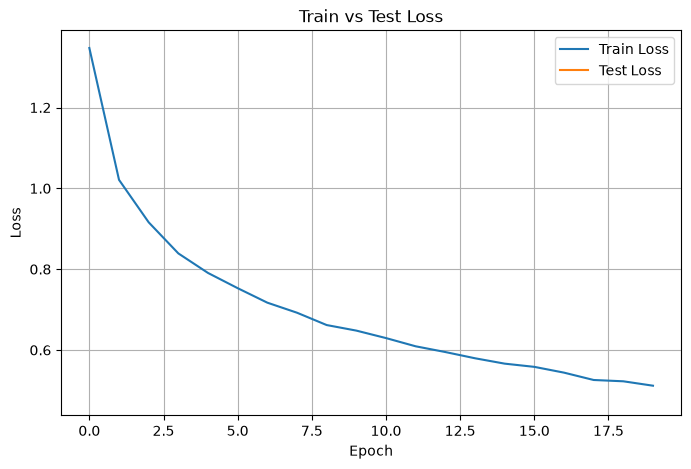

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(loss_history, label="Train Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Test Loss")

plt.legend()
plt.grid(True)

plt.show()

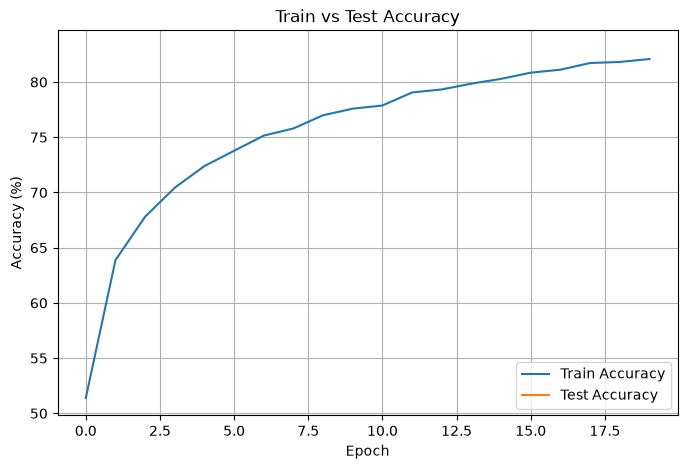

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(accuracy_history, label="Train Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Train vs Test Accuracy")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
torch.save(model.state_dict(), "cifar_model.pt")